In [1]:
import glob
import scipy
from scipy.interpolate import interp1d

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import os
import time
import pickle

import sklearn.metrics
import sklearn.decomposition

np.set_printoptions(suppress=True)

sample_templates = {0:'../templates/fluorescein_template.txt',
                   1:'../templates/tcqn_template.txt',
                   2:'../templates/ntcda_template.txt'}

or_files = glob.glob('*')

np.random.seed(3564)
initializer_seed = 10
initializer_scale = 1e-2

kernel_initializer = tf.keras.initializers.VarianceScaling(scale = initializer_scale, 
                                                            distribution = 'normal', seed = initializer_seed)

## Loading experimental files and configuring measurement window

In [2]:
pure = ['F','T','N']
mixtures = ['FN','FT','TN','FTN1','FTN2', 'FTN3','FTN4', 'FTN5']

xrd_pure = {k: pd.read_csv(f"../experimental_measurements/{k}.uxd",header=None, skiprows=58, sep='\t').iloc[:,:2] for k in pure}
xrd_mix = {k: pd.read_csv(f"../experimental_measurements/{k}.uxd",header=None, skiprows=58, sep='\t').iloc[:,:2] for k in mixtures}

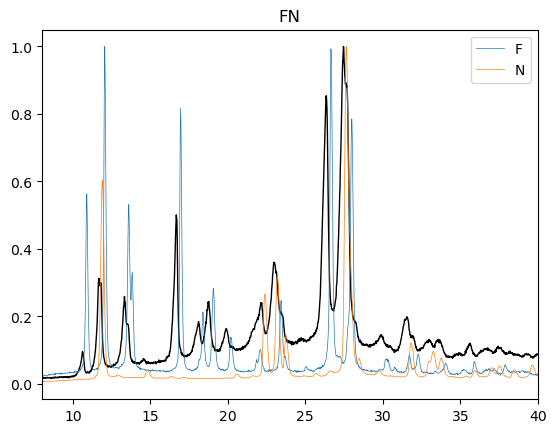

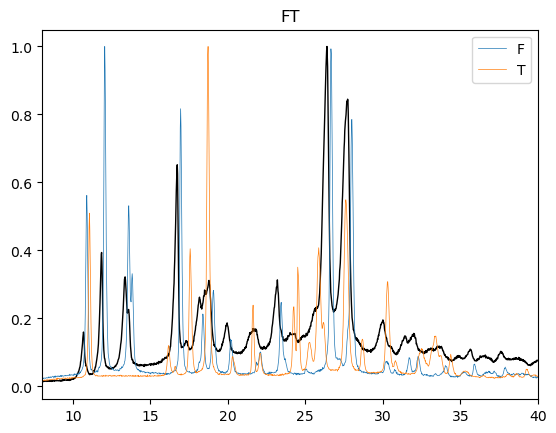

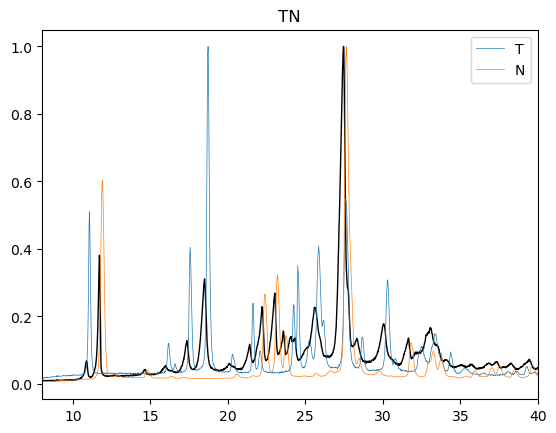

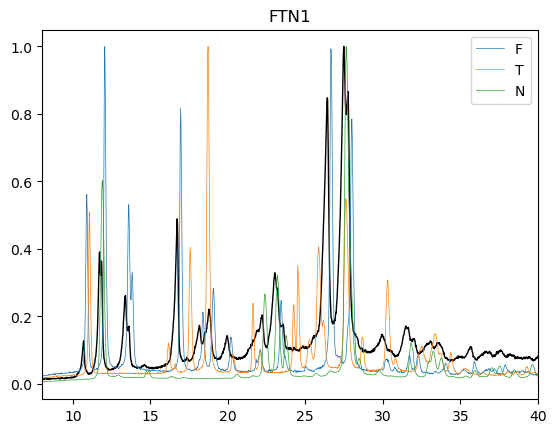

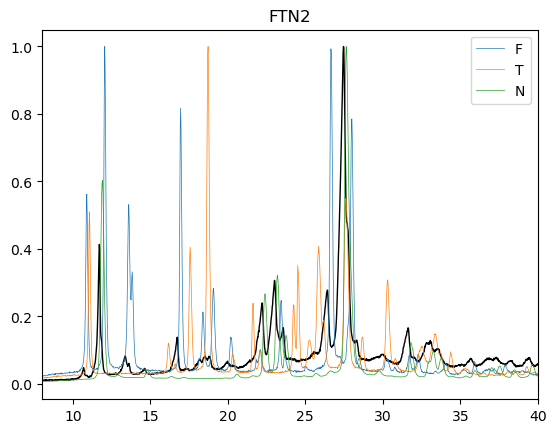

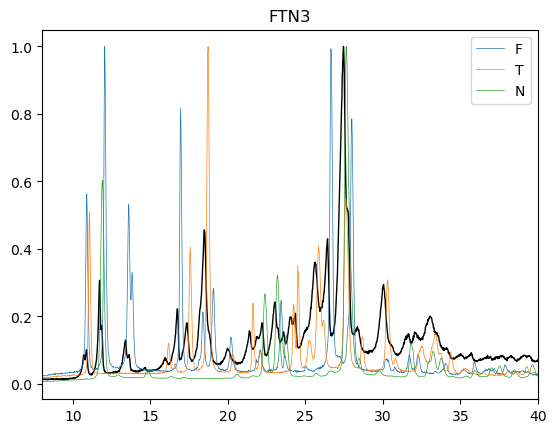

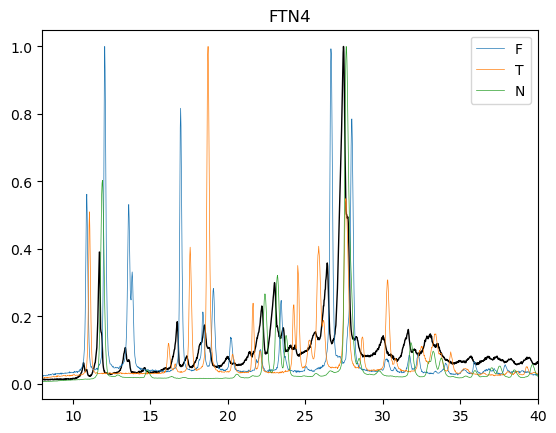

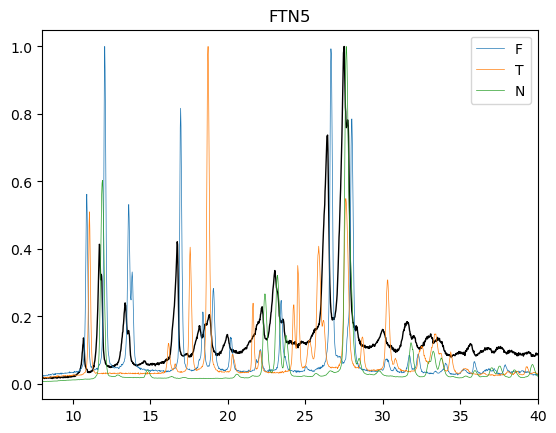

In [3]:
for k in xrd_mix.keys():
    
    plt.figure()
    plt.title(k)
    plt.plot(xrd_mix[k].iloc[:,0].values, xrd_mix[k].iloc[:,1]/np.max(xrd_mix[k].iloc[:,1]), linewidth=1, color='black')
    
    for kp in [i for i in k]:
        
        if kp in xrd_pure.keys():
            plt.plot(xrd_pure[kp].iloc[:,0].values, 
                     xrd_pure[kp].iloc[:,1]/np.max(xrd_pure[kp].iloc[:,1]), 
                     linewidth=0.5, label = kp)
        
    plt.legend(loc='best')
    plt.xlim(8,40)
    plt.show()


In [4]:
xmin = 15
xmax = 40

xsint = list()
for kp in xrd_pure.keys():
    
    dtheta = xrd_pure[kp].iloc[:,0].values
    xint = xrd_pure[kp].iloc[:,1].values
    
    xn = np.arange(xmin, xmax, (xmax-xmin)/2780)
    yn = scipy.interpolate.interp1d(dtheta, xint, kind='cubic')(xn)
    xsint += [yn]
xsint = np.stack(xsint)
xsint = np.expand_dims(xsint, axis=-1)

xmint = list()
for km in xrd_mix.keys():
    
    dtheta = xrd_mix[km].iloc[:,0].values
    xint = xrd_mix[km].iloc[:,1].values
    
    xn = np.arange(xmin, xmax, (xmax-xmin)/2780)
    yn = scipy.interpolate.interp1d(dtheta+0.4, xint, kind='cubic')(xn)
    xmint += [yn]
xmint = np.stack(xmint)
xmint = np.expand_dims(xmint, axis=-1)

xsint = (xsint - xsint.min(axis=(1,2), keepdims=True))/(xsint.max(axis=(1,2), keepdims=True) - xsint.min(axis=(1,2), keepdims=True))
xmint = (xmint - xmint.min(axis=(1,2), keepdims=True))/(xmint.max(axis=(1,2), keepdims=True) - xmint.min(axis=(1,2), keepdims=True))

xmint2 = np.asarray([[1,0,1],[1,1,0],[0,1,1],
                   [1,1,1],[1,1,1],[1,1,1],[1,1,1],[1,1,1]])

## Loading VAE model (VRB35)

In [5]:
n_hidden = 139*5

vae = tf.keras.models.load_model('../../VRB35.h5')
vae = tf.keras.Model(inputs=vae.inputs, outputs = vae.outputs, name='vae')
vae.trainable=False

encoder = tf.keras.Model(inputs=vae.inputs, outputs = vae.get_layer('z_vector').output, name='encoder')

## Loading the dataset and splitting into training and test sets

In [6]:
xrec = np.load('./generated_xrds.npy')[0]
xrec = np.expand_dims(xrec, axis=0)

df = pd.read_csv('./estimated_concentrations.csv')
df = df[['concF','concT', 'concN']]

idxmodel = df.index
dfmodel = df.iloc[idxmodel]

In [7]:
xmodel = (xrec[0] - xrec[0].min(axis=(1,2), keepdims=True))/(xrec[0].max(axis=(1,2), keepdims=True) - xrec[0].min(axis=(1,2), keepdims=True))
xmodel = xmodel[idxmodel]
ymodel = df[['concF','concT','concN']].values[idxmodel]/100

np.random.seed(10)
idxtest = np.random.choice(np.arange(xmodel.shape[0]),int(0.2*xmodel.shape[0]), replace=False)
idxtraval = np.setdiff1d(np.arange(xmodel.shape[0]), idxtest)

idxtraval = np.random.choice(idxtraval, len(idxtraval), replace=False)
idxtraval = np.random.choice(idxtraval, len(idxtraval), replace=False)
idxtraval = np.random.choice(idxtraval, len(idxtraval), replace=False)

ytraval = ymodel[idxtraval]
ytest = ymodel[idxtest]

xmodel2 = 1*(dfmodel.iloc[:,:3].values != 0)
xtraval2 = xmodel2[idxtraval]
xtest2 = xmodel2[idxtest]

xtraval = xmodel[idxtraval]
xtest = xmodel[idxtest]

###### Distribution of the generated diffraction patterns according to the most abundant phase

0 stands for fluorescein (F), 1 is for 7,7,8,8-tetracyanoquinodimethane (TCQN or T), and 2 is for 1,4,5,8-naphtalene tetracarboxylic dianhydride (NTCDA or N).

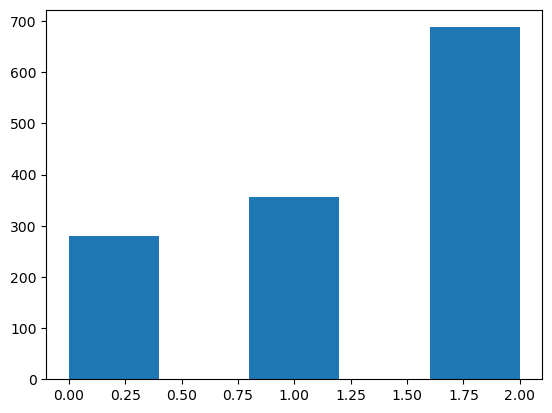

In [8]:
plt.figure()
plt.hist(ymodel.argmax(axis=-1), bins=5)
plt.show()

### Quick estimation of each phase concentration in the experimental mixed samples by comparison with the generated patterns using the cosine similarity. 

The cosine similarity value is indicated above the plot. The estimated phase concentrations appear as an array.

[0.7177 0.     0.2823]


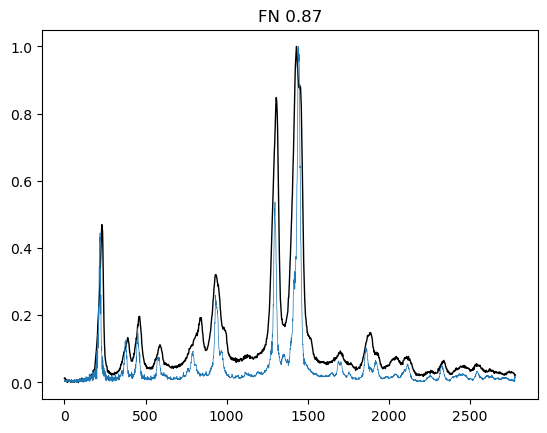

[0.7146 0.2854 0.    ]


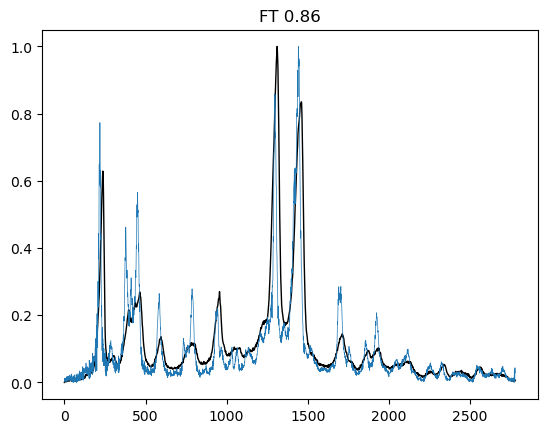

[0.      0.67825 0.32175]


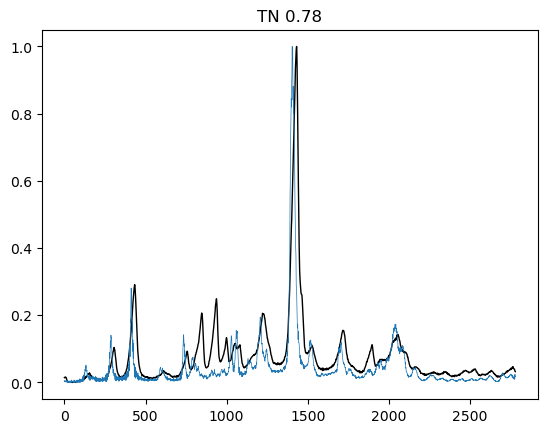

[0.52619 0.15526 0.31855]


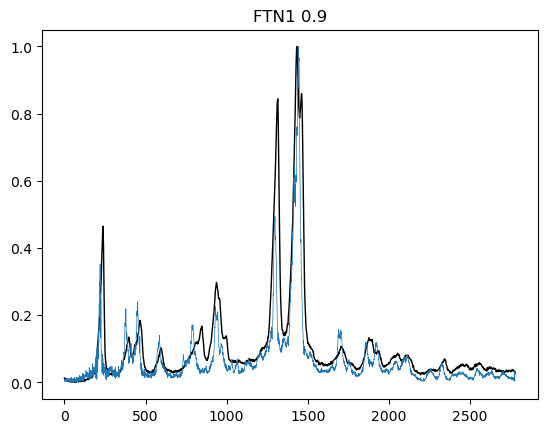

[0.25286 0.15117 0.59597]


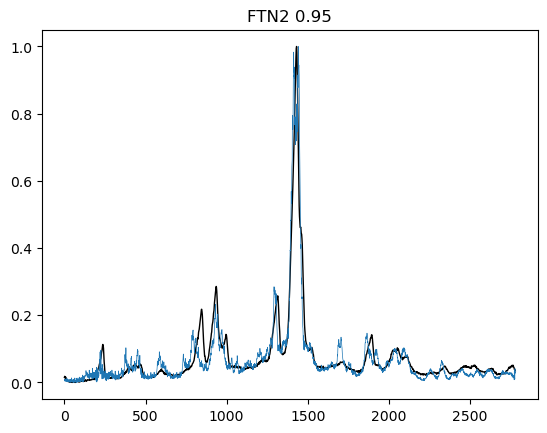

[0.29386 0.41444 0.2917 ]


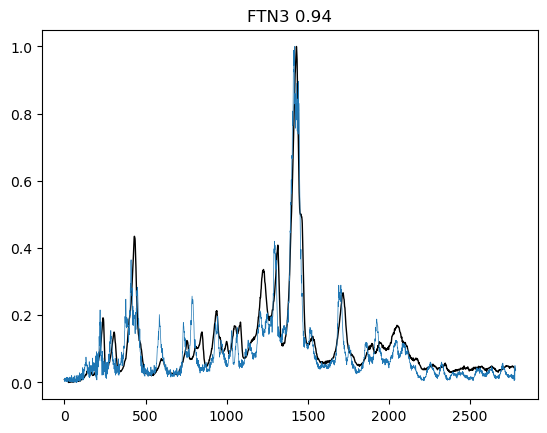

[0.30607 0.24742 0.44652]


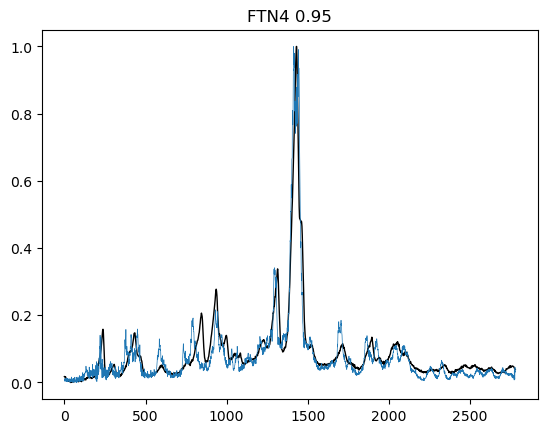

[0.48956 0.1804  0.33004]


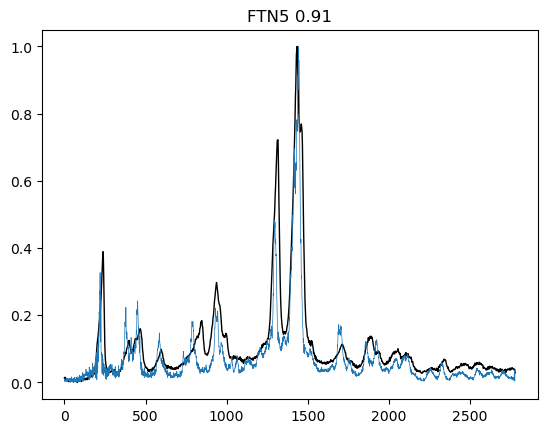

In [9]:
cossim = sklearn.metrics.pairwise.cosine_similarity(xmint[:,:,0], xmodel[:,:,0])
idx, ics = np.argmax(cossim, axis=1), np.max(cossim, axis=1)

for i in range(8):
    
    if i == 0: 
        corrected = cossim[i]*((df['concT'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)

    elif i == 1: 
        corrected = cossim[i]*((df['concN'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)        
    elif i == 2: 
        corrected = cossim[i]*((df['concF'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)
    else:
        iidx = idx[i]
        iics = ics[i]

    xmax = np.max(xmodel[iidx,:,0])
    plt.figure()
    print(ymodel[iidx])
    plt.title(f"{mixtures[i]} {np.round(iics,2)}")
    plt.plot(xmint[i,:,0], linewidth=1, color='black')
    plt.plot(xmodel[iidx,:,0]/xmax, linewidth=0.5)
    plt.show()

### Approximating the phase concentrations using the cosine similarity given by the pretrained model

The approached values were not as accurate as the ones obtained above where the full profile was used.

In [10]:
def cosine_similarity(xa, xb):
    
    xa = tf.linalg.normalize(xa, axis=-1)[0].numpy()
    xb = tf.linalg.normalize(xb, axis=-1)[0].numpy()
    
    return np.transpose(np.transpose(xa, (1,0,2)) @ np.transpose(xb, (1,2,0)), (1,2,0))

In [11]:
modelo = tf.keras.models.load_model('../../../pretrained_model.h5')
modelo.trainable = False

model_rb3 = tf.keras.models.Model(inputs = modelo.inputs[0], outputs = modelo.get_layer('activation_2').output, name='cropped_model_rb3')

xp = model_rb3.predict(xmodel)
xps = model_rb3.predict(xsint)
xpm = model_rb3.predict(xmint)

xptraval = xp[idxtraval]
xptest = xp[idxtest]

xanchor = np.reshape(np.transpose(cosine_similarity(xps, xp), (1,2,0)), (xp.shape[0],-1))
xeval = np.reshape(cosine_similarity(xpm, xps), (xpm.shape[0],-1))

1/1 [==============================] - 0s 54ms/step


[0.29919 0.      0.70081]


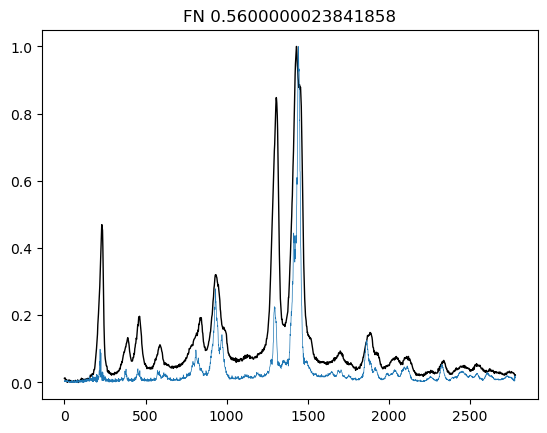

[0.67628 0.32372 0.     ]


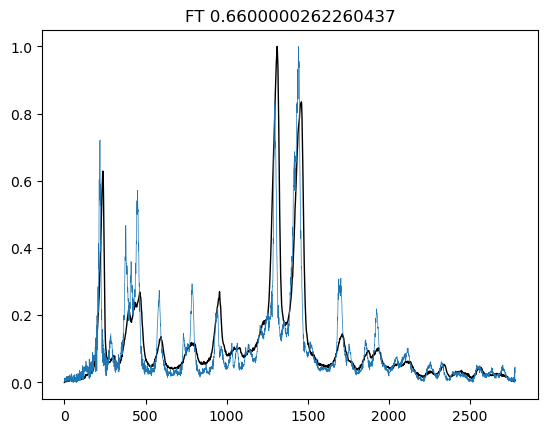

[0.      0.37744 0.62256]


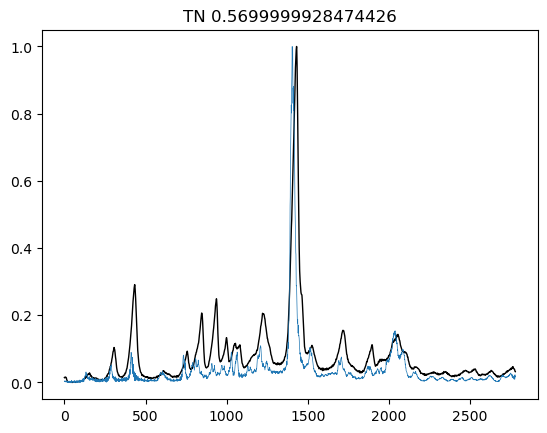

[0.33985 0.13334 0.52681]


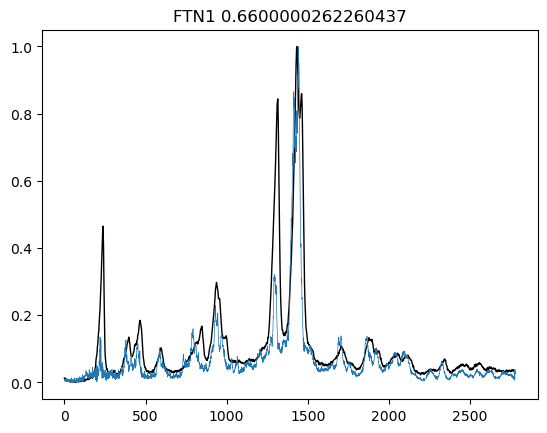

[0.17264 0.05921 0.76815]


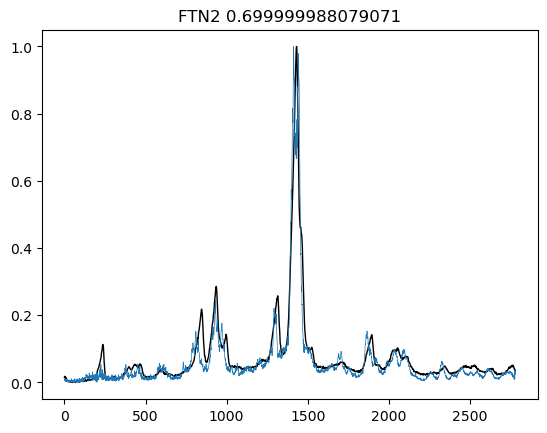

[0.18321 0.47678 0.34002]


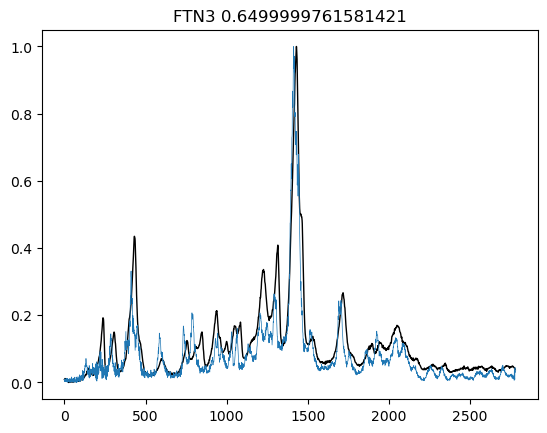

[0.2067  0.19011 0.60319]


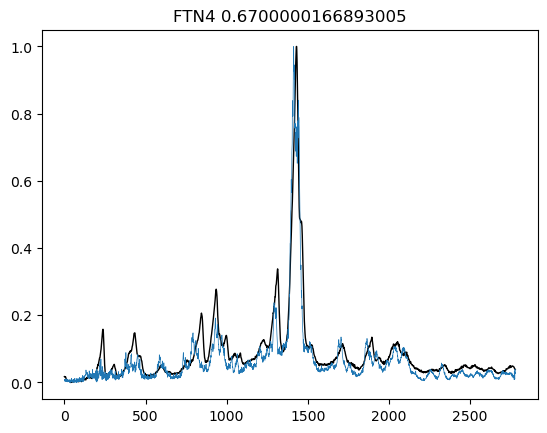

[0.29392 0.18893 0.51715]


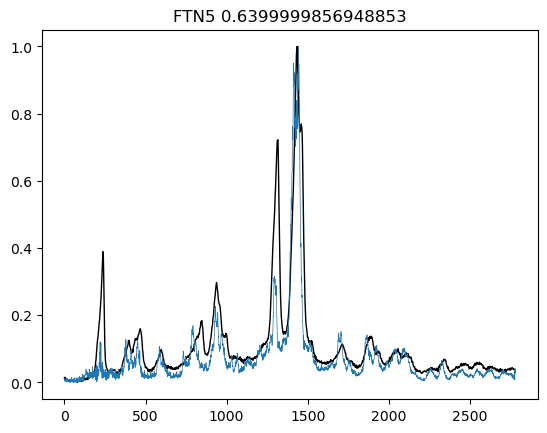

In [12]:
cossim = np.transpose(cosine_similarity(xp, xpm), (1,2,0)).mean(axis=1)
idx, ics = np.argmax(cossim, axis=1), np.max(cossim, axis=1)

for i in range(8):
    
    if i == 0: 
        corrected = cossim[i]*((df['concT'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)

    elif i == 1: 
        corrected = cossim[i]*((df['concN'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)        
    elif i == 2: 
        corrected = cossim[i]*((df['concF'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)
    else:
        iidx = idx[i]
        iics = ics[i]

    xmax = np.max(xmodel[iidx,:,0])
    plt.figure()
    print(ymodel[iidx])
    plt.title(f"{mixtures[i]} {np.round(iics,2)}")
    plt.plot(xmint[i,:,0], linewidth=1, color='black')
    plt.plot(xmodel[iidx,:,0]/xmax, linewidth=0.5)
    plt.show()

## Definition of the regression models

In the next cell, two different neural networks are used to estimate the phase concentration of the ternary system. 
1. In one model `pmregressor`, the features given by the third block (RB3) of the pretrained model are passed through two *Dense* hidden layers with *relu* activation. The output is calculated with a *softmax* function. 
2. In the second model `lsregressor`, the full generated diffraction pattern is first passed to the encoder part of the model **VRB35** to obtain the latent space (ls) representation. Then, this ls-representation is passes thorugh a residual system of two *hidden* Dense  layers with *relu* activation. The output is given by a *softmax* function.

In both neural networks, the output is conditioned to the presence of a phase.

In [13]:
def pmregressor(name=''):
    input_layer = tf.keras.Input(shape=(139,96))
    input_layer2 = tf.keras.Input(shape=(3,))

    x = tf.keras.layers.Dense(20, kernel_initializer = kernel_initializer)(input_layer)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.LeakyReLU(0.)(x)
    x = tf.keras.layers.Dropout(0.125)(x)

    x = tf.keras.layers.Dense(x.shape[-1]//4, kernel_initializer = kernel_initializer)(x)
    x = tf.keras.layers.LeakyReLU(0.)(x)
    x = tf.keras.layers.Dropout(0.125)(x)

    x = tf.keras.layers.Dense(3, kernel_initializer = kernel_initializer)(x)
    output = tf.keras.layers.Add()([x, -1e8*(1-input_layer2)])
    output = tf.keras.layers.Activation('softmax')(output)

    pann = tf.keras.Model(inputs=[input_layer, input_layer2],
                          outputs=output, name=f"pretrained_features_{name}")
    pann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss = tf.keras.losses.MeanSquaredError())
    
    return pann

def lsregressor(name='', train_samples = 1, batch_size=1, epochs=1):
    input_layer = tf.keras.Input(shape=(2780,1))
    input_layer2 = tf.keras.Input(shape=(3,))
    xi = encoder(input_layer, training=False)

    x = tf.keras.layers.Dense(xi.shape[-1]*4, kernel_initializer=kernel_initializer)(xi)
    x = tf.keras.layers.LeakyReLU(0.)(x)
    x = tf.keras.layers.Dropout(0.125)(x)

    x = tf.keras.layers.Dense(xi.shape[-1], kernel_initializer=kernel_initializer)(x)
    x = tf.keras.layers.Add()([x, xi])
    x = tf.keras.layers.LeakyReLU(0.)(x)
    x = tf.keras.layers.Dropout(0.125)(x)

    x = tf.keras.layers.Dense(3, kernel_initializer = kernel_initializer)(x)
    output = tf.keras.layers.Add()([x, -1e8*(1-input_layer2)])
    output = tf.keras.layers.Activation('softmax')(output)

    ann = tf.keras.Model(inputs=[input_layer, input_layer2], outputs=output, name=f"ls_{name}")

    INIT_LR = 1e-4        
    MIN_LR = 1e-6           
    lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=INIT_LR,
        first_decay_steps=(train_samples//batch_size)*epochs,  
        t_mul=1.0,               
        m_mul=1.0,               
        alpha=MIN_LR / INIT_LR   
    )

    ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss = tf.keras.losses.MeanAbsoluteError())
    
    return ann

In [14]:
models = dict()
predictions = dict()
num_models = 1
for item in range(num_models):
    print('Set', item+1,'/',num_models)
    
    models[item+1] = dict()
    predictions[item+1] = dict()
    
    pann = pmregressor(name=item+1)
    pann.fit([xptraval, xtraval2], ytraval, batch_size=128, epochs=80, validation_data=([xptest, xtest2], ytest), verbose=0)
    ptest_p = pann.predict([xptest, xtest2])
    pann.trainable=False
    print('Pretrained features', sklearn.metrics.r2_score(ytest, ptest_p))
    prediction = np.round(pann.predict([xpm, xmint2]),4)
    print(prediction,'\n')
    
    predictions[item+1]['pmodel'] = prediction
    models[item+1]['pmodel'] = pann
    
    lsann = lsregressor(name=item+1, train_samples=xtraval.shape[0], batch_size=32, epochs=250)
    lsann.fit([xtraval, xtraval2], ytraval, batch_size=32, epochs=250, validation_data = ([xtest, xtest2], ytest), verbose=0)
    ptest_ls = lsann.predict([xtest, xtest2])
    lsann.trainable=False
    print('LS features', sklearn.metrics.r2_score(ytest, ptest_ls))
    prediction = np.round(lsann.predict([xmint, xmint2]),4)
    print(prediction,'\n')
    
    predictions[item+1]['lsmodel'] = prediction
    models[item+1]['lsmodel'] = lsann
    
    

Set 1 / 1
9/9 [==============================] - 0s 3ms/step
Pretrained features 0.9988495933455823
1/1 [==============================] - 0s 24ms/step
[[0.5162 0.     0.4838]
 [0.714  0.286  0.    ]
 [0.     0.5166 0.4834]
 [0.4463 0.1504 0.4032]
 [0.2498 0.1331 0.6171]
 [0.235  0.4331 0.3319]
 [0.2702 0.2553 0.4744]
 [0.4377 0.178  0.3843]] 

9/9 [==============================] - 0s 3ms/step
LS features 0.9985578237211477
1/1 [==============================] - 0s 32ms/step
[[0.4635 0.     0.5365]
 [0.6317 0.3683 0.    ]
 [0.     0.3054 0.6946]
 [0.4021 0.1189 0.479 ]
 [0.1851 0.0832 0.7317]
 [0.2018 0.3389 0.4593]
 [0.2284 0.168  0.6037]
 [0.3753 0.1342 0.4905]] 



1136 [0.5144 0.     0.4856]


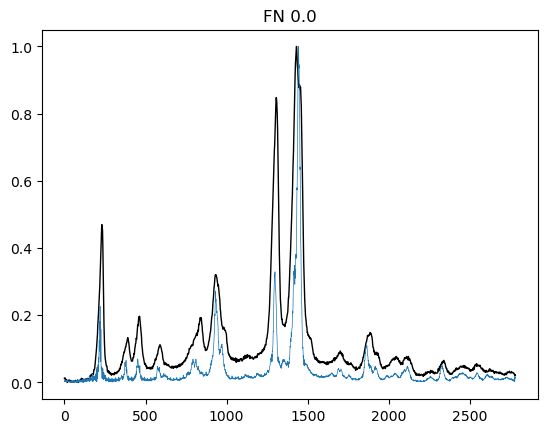

1172 [0.7146 0.2854 0.    ]


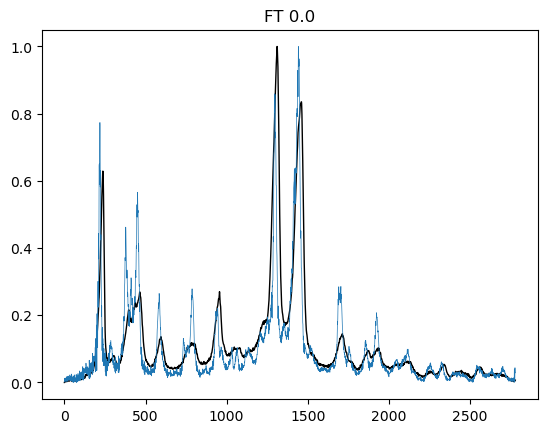

32 [0.      0.53282 0.46718]


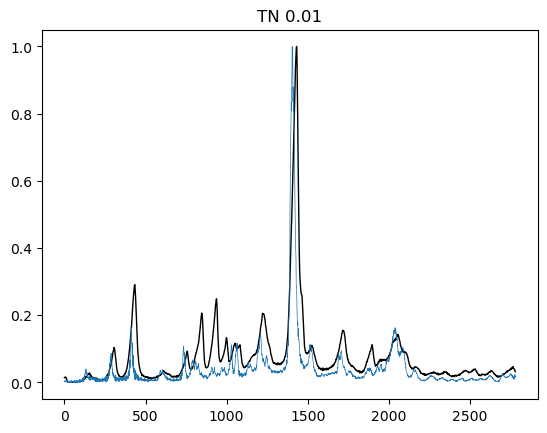

1039 [0.44031 0.15756 0.40213]


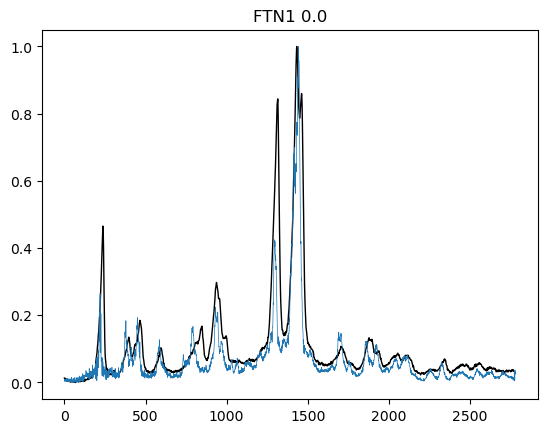

874 [0.25286 0.15117 0.59597]


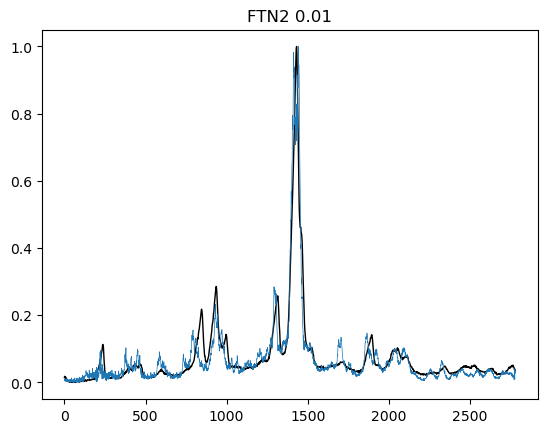

883 [0.23243 0.44849 0.31908]


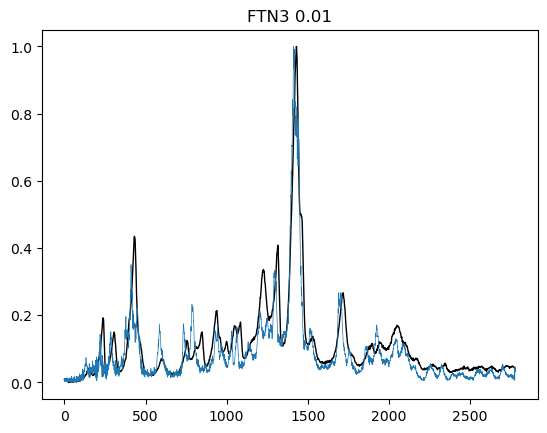

908 [0.2715  0.26081 0.46768]


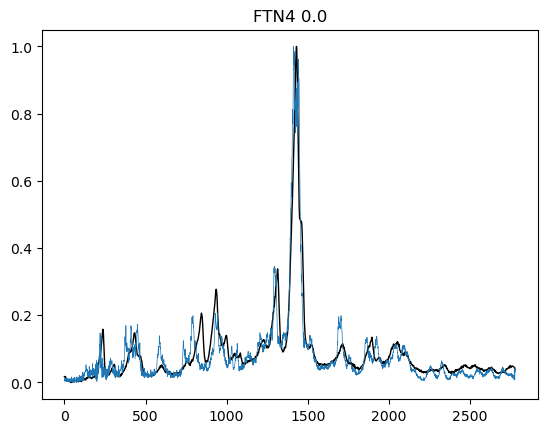

1040 [0.44708 0.18181 0.37111]


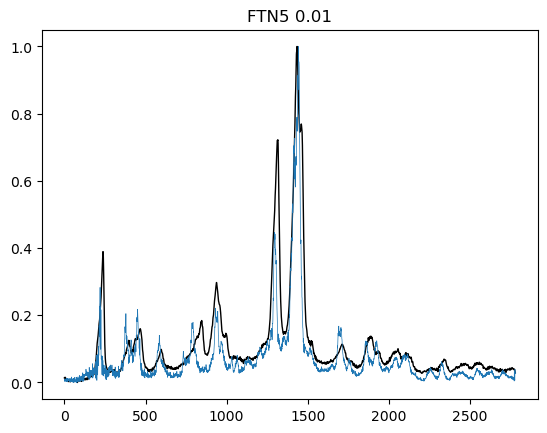

In [15]:
ypred = np.stack([predictions[i+1]['pmodel'] for i in range(1)]).mean(axis=0)
mae = np.mean(np.abs(np.transpose(ymodel)[...,None] - np.transpose(ypred)[:,None,:]), axis=0).T 
idx, ics = np.argmin(mae, axis=1), np.min(mae, axis=1)

for i in range(8):
    xmax = np.max(xmint[i,:,0])
    print(idx[i], ymodel[idx[i]])
    plt.figure()
    plt.title(f"{mixtures[i]} {np.round(ics[i],2)}")
    plt.plot(xmint[i,:,0]/xmax, linewidth=1, color='black')
    plt.plot(xmodel[idx[i],:,0], linewidth=0.5)
    
    plt.show()

1116 [0.46172 0.      0.53828]


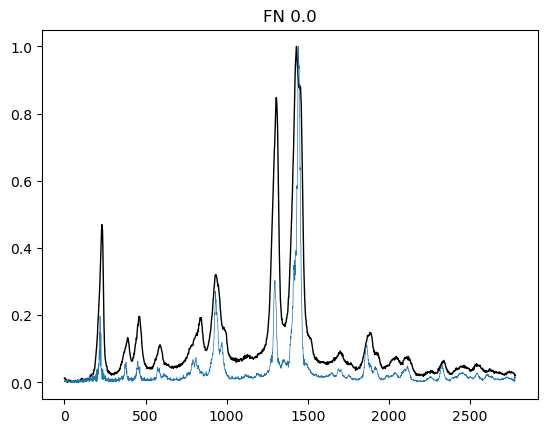

1135 [0.63575 0.36425 0.     ]


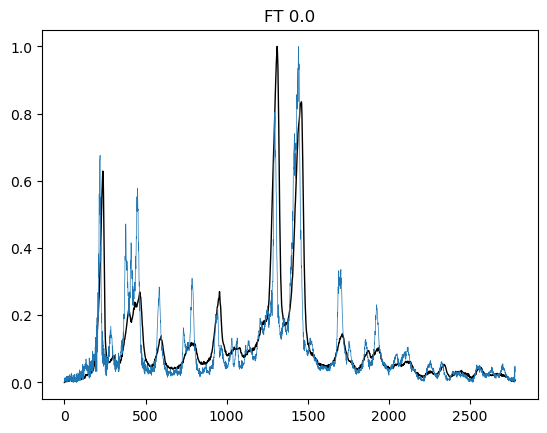

78 [0.02191 0.30332 0.67477]


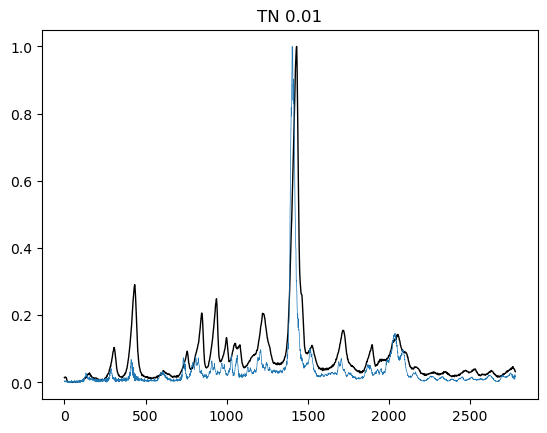

1013 [0.40347 0.12476 0.47176]


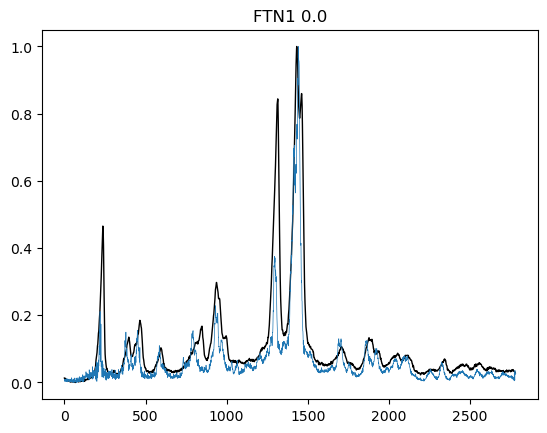

809 [0.18159 0.07712 0.74129]


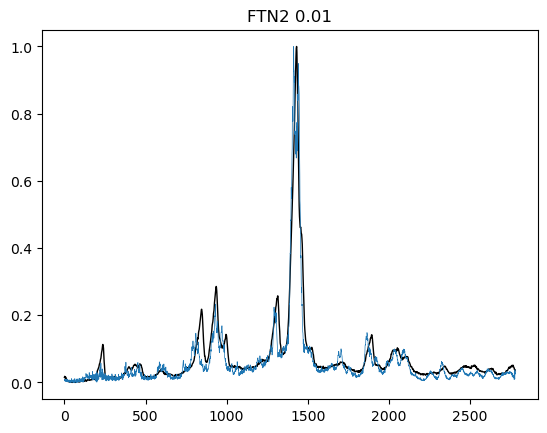

818 [0.19219 0.34969 0.45811]


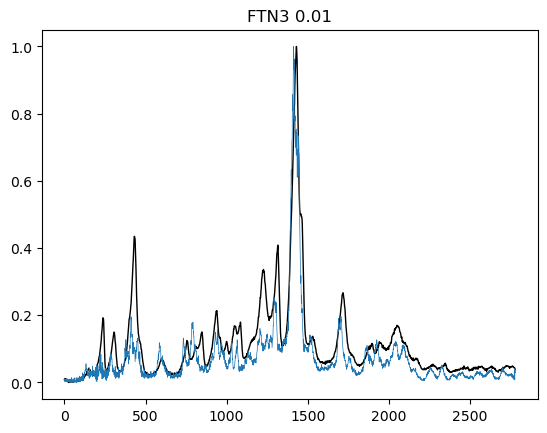

844 [0.22908 0.16999 0.60093]


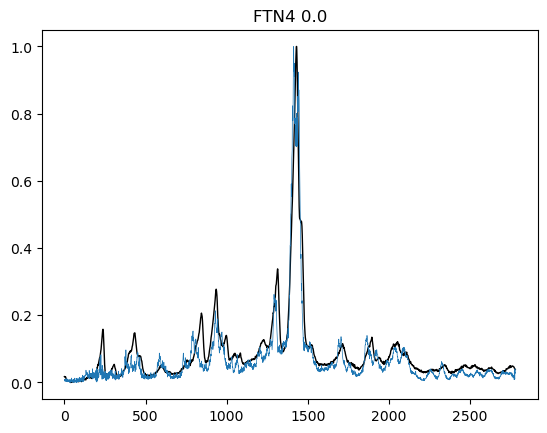

960 [0.37121 0.11441 0.51438]


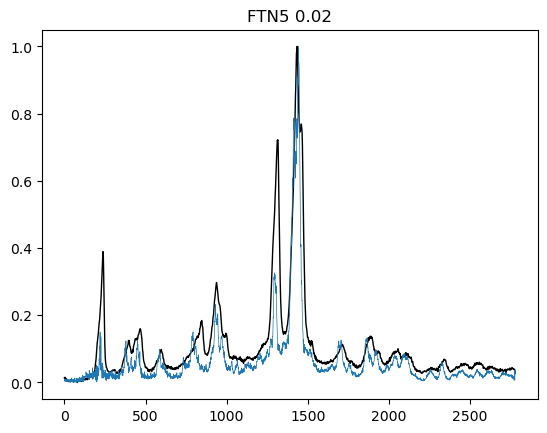

In [16]:
ypred = np.stack([predictions[i+1]['lsmodel'] for i in range(1)]).mean(axis=0)
mae = np.mean(np.abs(np.transpose(ymodel)[...,None] - np.transpose(ypred)[:,None,:]), axis=0).T 
idx, ics = np.argmin(mae, axis=1), np.min(mae, axis=1)

for i in range(8):
    xmax = np.max(xmint[i,:,0])
    print(idx[i], ymodel[idx[i]])
    plt.figure()
    plt.title(f"{mixtures[i]} {np.round(ics[i],2)}")
    plt.plot(xmint[i,:,0]/xmax, linewidth=1, color='black')
    plt.plot(xmodel[idx[i],:,0], linewidth=0.5)
    
    plt.show()